 **Datenimport und initiale Validierung**

Der monatliche Datensatz wird aus der Excel-Datei eingelesen und zunächst auf das Vorhandensein zentraler Variablen überprüft. Anschließend wird die Datumsspalte in ein einheitliches Datumsformat konvertiert und der Datensatz chronologisch sortiert. Abschließend werden die Datenstruktur sowie die ersten und letzten Beobachtungen kontrolliert, um eine korrekte Grundlage für die explorative Datenanalyse sicherzustellen.

In [170]:
import pandas as pd

# Lade ausschließlich die angegebene Excel-Datei
df = pd.read_excel("master_dataset_monthly.xlsx")

# Definiere die obligatorischen Spalten, die vorhanden sein müssen
required_columns = [
    'Datum',
    'Industrial_Production',
    'Manufacturing_Output',
    'Capital_Goods_Output',
    'Intermediate_Goods_Output'
]

# Überprüfe, ob alle obligatorischen Spalten im DataFrame vorhanden sind
missing_required_columns = [col for col in required_columns if col not in df.columns]

if missing_required_columns:
    raise ValueError(
        f"Die folgenden obligatorischen Spalten fehlen im Datensatz und "
        f"die Analyse kann nicht fortgesetzt werden: {missing_required_columns}"
    )
else:
    print(
        "Alle obligatorischen Spalten ('Datum', 'Industrial_Production', "
        "'Manufacturing_Output', 'Capital_Goods_Output', "
        "'Intermediate_Goods_Output') sind vorhanden."
    )

# Konvertiere die Spalte 'Datum' in das datetime-Format
# 'errors=coerce' wandelt ungültige Datumsformate in NaT um, falls vorhanden
df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')

# Sortiere den Datensatz nach der Spalte 'Datum'
df = df.sort_values(by='Datum').reset_index(drop=True)

# Prüfe die Datentypen nach der Konvertierung
print("\nDatentypen nach der Datums-Konvertierung und Sortierung:")
df.info()

# Zeige die ersten fünf Beobachtungen
print("\nErste 5 Beobachtungen:")
display(df.head())

# Zeige die letzten fünf Beobachtungen
print("\nLetzte 5 Beobachtungen:")
display(df.tail())

Alle obligatorischen Spalten ('Datum', 'Industrial_Production', 'Manufacturing_Output', 'Capital_Goods_Output', 'Intermediate_Goods_Output') sind vorhanden.

Datentypen nach der Datums-Konvertierung und Sortierung:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Datum                                  425 non-null    datetime64[ns]
 1   Industrial_Production                  424 non-null    float64       
 2   Manufacturing_Output                   424 non-null    float64       
 3   Capital_Goods_Output                   424 non-null    float64       
 4   Intermediate_Goods_Output              424 non-null    float64       
 5   Consumer_Goods_Output                  424 non-null    float64       
 6   Orders_Abroad_Intermediate_Capital     424 non-null    float64       
 7   

,Datum,Industrial_Production,Manufacturing_Output,Capital_Goods_Output,Intermediate_Goods_Output,Consumer_Goods_Output,Orders_Abroad_Intermediate_Capital,Construction_Orders,Unemployment_Rate,Employment,...,Domestic_Capital_Goods_Orders,Domestic_Intermediate_Goods_Orders,Euribor_3M,Brent_Oil,Production_Expectations_Manufacturing,Business_Situation_Services,Business_Situation_Retail,Term_Spread_Germany,Exports,Imports
0,1991-01-31,81.8,80.4,74.0,72.5,105.0,36.6,102.0,NaN,39312,...,54.6,61.1,9.35,23.57,4.8,NaN,34.3,-0.4225,59.03,55.84
1,1991-02-28,80.9,79.2,72.6,71.5,103.1,34.6,104.0,NaN,39188,...,50.7,59.9,9.08,19.54,5.5,NaN,27.2,-0.7300,55.82,52.34
2,1991-03-31,80.2,78.5,72.3,71.1,102.8,35.7,108.6,NaN,39065,...,53.1,59.0,9.09,19.08,3.3,NaN,36.5,-0.6625,55.60,52.87
3,1991-04-30,79.5,77.9,71.3,70.8,101.8,35.3,106.9,NaN,39056,...,50.5,59.5,9.18,19.18,3.9,NaN,33.4,-0.8225,51.01,51.28
4,1991-05-31,78.7,76.9,70.2,70.1,99.6,34.7,109.0,NaN,39021,...,50.8,58.0,9.08,19.19,6.5,NaN,22.6,-0.6850,56.00,56.76



Letzte 5 Beobachtungen:


,Datum,Industrial_Production,Manufacturing_Output,Capital_Goods_Output,Intermediate_Goods_Output,Consumer_Goods_Output,Orders_Abroad_Intermediate_Capital,Construction_Orders,Unemployment_Rate,Employment,...,Domestic_Capital_Goods_Orders,Domestic_Intermediate_Goods_Orders,Euribor_3M,Brent_Oil,Production_Expectations_Manufacturing,Business_Situation_Services,Business_Situation_Retail,Term_Spread_Germany,Exports,Imports
420,2026-01-31,91.6,92.0,98.8,83.1,92.6,86.6,87.4,6.3,45879,...,91.4,79.4,2.028,66.60,-2.8,-2.8,-24.0,NaN,130.43,110.19
421,2026-02-28,91.6,92.0,98.7,83.6,91.6,91.7,92.7,6.3,45863,...,92.4,80.9,2.011,70.89,1.4,-6.5,-25.1,NaN,135.10,115.46
422,2026-03-31,90.9,91.5,97.6,84.0,90.4,96.3,92.5,6.3,45839,...,93.9,87.9,2.109,103.13,-0.5,-4.0,-15.5,NaN,135.44,120.70
423,2026-04-30,90.9,91.5,96.1,85.2,92.1,92.9,92.5,6.4,45833,...,91.2,84.0,2.175,117.29,-4.0,-13.5,-20.2,NaN,136.62,122.10
424,2026-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.3,45825,...,NaN,NaN,2.226,107.14,-5.7,-8.2,-21.3,NaN,NaN,NaN


**Datensatzbeschreibung**

In diesem Schritt werden die grundlegenden Eigenschaften des Datensatzes zusammengefasst. Dazu gehören die Anzahl der Beobachtungen und Variablen, der Untersuchungszeitraum sowie die Datentypen der enthaltenen Merkmale. Zusätzlich werden die ersten und letzten Beobachtungen angezeigt, um die zeitliche Abdeckung und Struktur des Datensatzes zu kontrollieren.

In [171]:
print("\n--- Datensatzbeschreibung ---")

# Anzahl Beobachtungen
num_observations = df.shape[0]
print(f"Anzahl Beobachtungen: {num_observations}")

# Anzahl Variablen
num_variables = df.shape[1] # Hinzugefügte Zeile zur Definition von num_variables
print(f"Anzahl Spalten insgesamt: {df.shape[1]}")
print(f"Anzahl makroökonomischer Variablen ohne Datum: {df.shape[1] - 1}")
print(f"Anzahl Variablen: {num_variables}")

# Untersuchungszeitraum (extrahiert aus der 'Datum'-Spalte)
# Sicherstellen, dass 'Datum' korrekt als Datetime erkannt wird
if 'Datum' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Datum']):
    untersuchungszeitraum_start = df['Datum'].min().strftime('%Y-%m-%d')
    untersuchungszeitraum_ende = df['Datum'].max().strftime('%Y-%m-%d')
    print(f"Untersuchungszeitraum: {untersuchungszeitraum_start} bis {untersuchungszeitraum_ende}")
else:
    print("Untersuchungszeitraum kann nicht präzise bestimmt werden, da keine gültige Datumsspalte gefunden oder konvertierbar ist.")

# Datentypen
print("\nDatentypen der Variablen:")
df.info()

# Erste fünf Beobachtungen (bereits in Schritt 1 gezeigt, aber hier der Vollständigkeit halber nochmal)
print("\nErste 5 Beobachtungen des DataFrames:")
display(df.head())

# Letzte fünf Beobachtungen (bereits in Schritt 1 gezeigt, aber hier der Vollständigkeit halber nochmal)
print("\nLetzte 5 Beobachtungen des DataFrames:")
display(df.tail())


--- Datensatzbeschreibung ---
Anzahl Beobachtungen: 425
Anzahl Spalten insgesamt: 29
Anzahl makroökonomischer Variablen ohne Datum: 28
Anzahl Variablen: 29
Untersuchungszeitraum: 1991-01-31 bis 2026-05-31

Datentypen der Variablen:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Datum                                  425 non-null    datetime64[ns]
 1   Industrial_Production                  424 non-null    float64       
 2   Manufacturing_Output                   424 non-null    float64       
 3   Capital_Goods_Output                   424 non-null    float64       
 4   Intermediate_Goods_Output              424 non-null    float64       
 5   Consumer_Goods_Output                  424 non-null    float64       
 6   Orders_Abroad_Intermediate_Capital     424 non-null    fl

,Datum,Industrial_Production,Manufacturing_Output,Capital_Goods_Output,Intermediate_Goods_Output,Consumer_Goods_Output,Orders_Abroad_Intermediate_Capital,Construction_Orders,Unemployment_Rate,Employment,...,Domestic_Capital_Goods_Orders,Domestic_Intermediate_Goods_Orders,Euribor_3M,Brent_Oil,Production_Expectations_Manufacturing,Business_Situation_Services,Business_Situation_Retail,Term_Spread_Germany,Exports,Imports
0,1991-01-31,81.8,80.4,74.0,72.5,105.0,36.6,102.0,NaN,39312,...,54.6,61.1,9.35,23.57,4.8,NaN,34.3,-0.4225,59.03,55.84
1,1991-02-28,80.9,79.2,72.6,71.5,103.1,34.6,104.0,NaN,39188,...,50.7,59.9,9.08,19.54,5.5,NaN,27.2,-0.7300,55.82,52.34
2,1991-03-31,80.2,78.5,72.3,71.1,102.8,35.7,108.6,NaN,39065,...,53.1,59.0,9.09,19.08,3.3,NaN,36.5,-0.6625,55.60,52.87
3,1991-04-30,79.5,77.9,71.3,70.8,101.8,35.3,106.9,NaN,39056,...,50.5,59.5,9.18,19.18,3.9,NaN,33.4,-0.8225,51.01,51.28
4,1991-05-31,78.7,76.9,70.2,70.1,99.6,34.7,109.0,NaN,39021,...,50.8,58.0,9.08,19.19,6.5,NaN,22.6,-0.6850,56.00,56.76



Letzte 5 Beobachtungen des DataFrames:


,Datum,Industrial_Production,Manufacturing_Output,Capital_Goods_Output,Intermediate_Goods_Output,Consumer_Goods_Output,Orders_Abroad_Intermediate_Capital,Construction_Orders,Unemployment_Rate,Employment,...,Domestic_Capital_Goods_Orders,Domestic_Intermediate_Goods_Orders,Euribor_3M,Brent_Oil,Production_Expectations_Manufacturing,Business_Situation_Services,Business_Situation_Retail,Term_Spread_Germany,Exports,Imports
420,2026-01-31,91.6,92.0,98.8,83.1,92.6,86.6,87.4,6.3,45879,...,91.4,79.4,2.028,66.60,-2.8,-2.8,-24.0,NaN,130.43,110.19
421,2026-02-28,91.6,92.0,98.7,83.6,91.6,91.7,92.7,6.3,45863,...,92.4,80.9,2.011,70.89,1.4,-6.5,-25.1,NaN,135.10,115.46
422,2026-03-31,90.9,91.5,97.6,84.0,90.4,96.3,92.5,6.3,45839,...,93.9,87.9,2.109,103.13,-0.5,-4.0,-15.5,NaN,135.44,120.70
423,2026-04-30,90.9,91.5,96.1,85.2,92.1,92.9,92.5,6.4,45833,...,91.2,84.0,2.175,117.29,-4.0,-13.5,-20.2,NaN,136.62,122.10
424,2026-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.3,45825,...,NaN,NaN,2.226,107.14,-5.7,-8.2,-21.3,NaN,NaN,NaN


**Datenqualität**

Dieser Schritt widmet sich der systematischen Untersuchung der Datenqualität durch die Analyse fehlender Werte und das Aufspüren doppelter Beobachtungen. Ziel ist die Identifikation potenzieller Unvollständigkeiten oder Redundanzen im Datensatz. Eine fundierte Bewertung der Datenqualität ist unerlässlich, da fehlende Werte oder Duplikate die Ergebnisse von statistischen Analysen und Machine-Learning-Modellen signifikant verzerren können und somit die Robustheit der Forschung beeinträchtigen.


--- Datenqualitätsanalyse (Fehlende Werte, Duplikate, Konsistenz) ---

1. Analyse fehlender Werte:
Übersicht fehlender Werte pro Variable:


,Anzahl fehlender Werte,Prozentsatz fehlender Werte
Business_Situation_Services,51,12.000000
Term_Spread_Germany,29,6.823529
Unemployment_Rate,11,2.588235
Intermediate_Goods_Output,1,0.235294
Industrial_Production,1,0.235294
Manufacturing_Output,1,0.235294
Capital_Goods_Output,1,0.235294
Construction_Orders,1,0.235294
Orders_Abroad_Intermediate_Capital,1,0.235294
Consumer_Goods_Output,1,0.235294


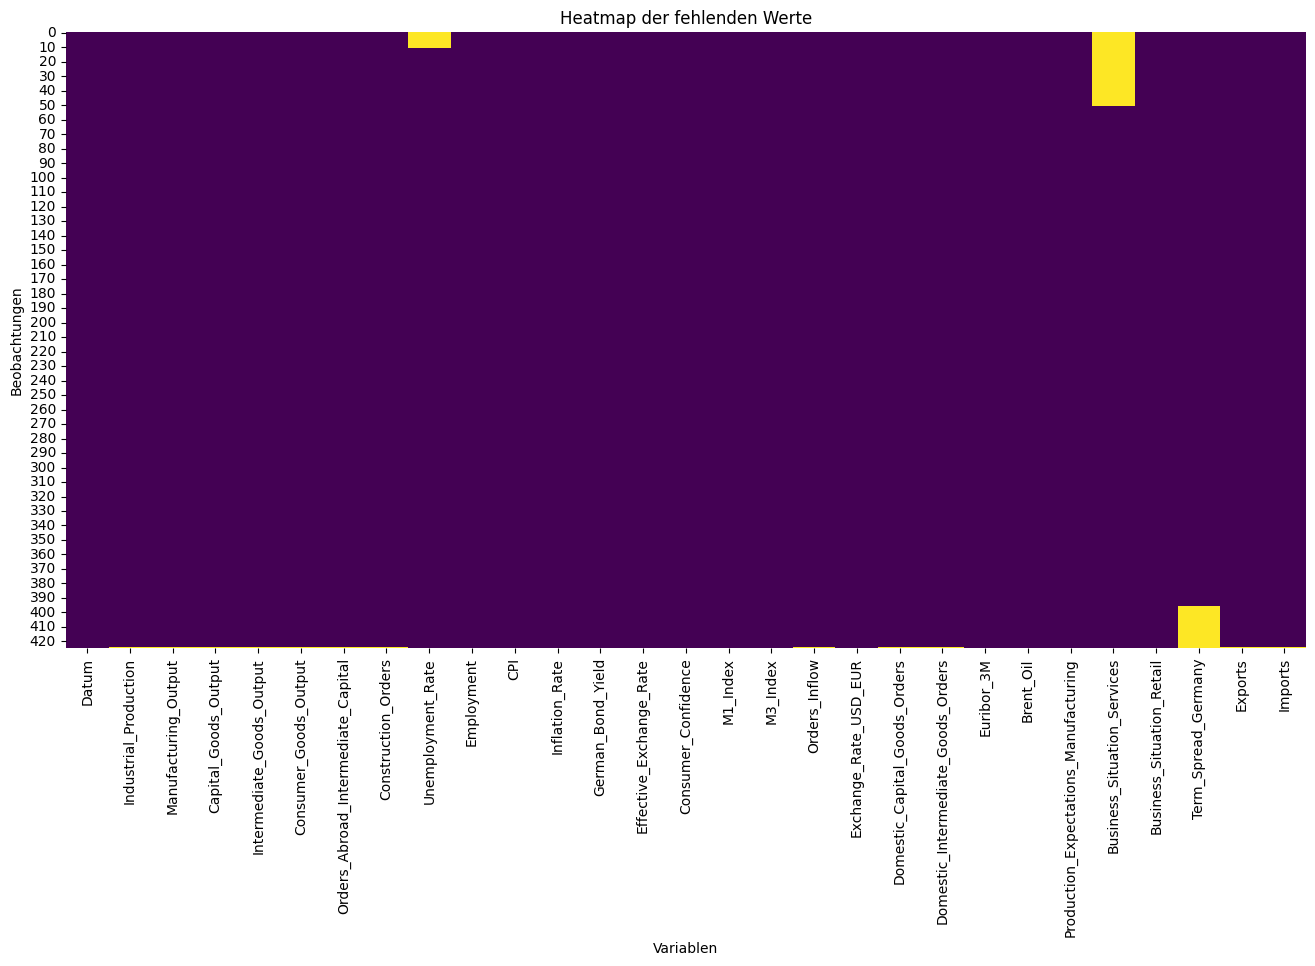


2. Überprüfung auf doppelte Beobachtungen:
Keine doppelten Beobachtungen im Datensatz gefunden.

3. Datenkonsistenz (Datentypen):
Die Datentypen wurden bereits in Schritt 1 geprüft und sind konsistent mit den erwarteten Formaten:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Datum                                  425 non-null    datetime64[ns]
 1   Industrial_Production                  424 non-null    float64       
 2   Manufacturing_Output                   424 non-null    float64       
 3   Capital_Goods_Output                   424 non-null    float64       
 4   Intermediate_Goods_Output              424 non-null    float64       
 5   Consumer_Goods_Output                  424 non-null    float64       
 6   Orders_Abroad_Intermediate_Capital     424 non-null    floa

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Datenqualitätsanalyse (Fehlende Werte, Duplikate, Konsistenz) ---")

# 1. Analyse fehlender Werte
print("\n1. Analyse fehlender Werte:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Anzahl fehlender Werte': missing_values,
    'Prozentsatz fehlender Werte': missing_percentage
})

# Filter to show only columns with missing values
missing_info = missing_info[missing_info['Anzahl fehlender Werte'] > 0]

if missing_info.empty:
    print("Keine fehlenden Werte im Datensatz gefunden.")
else:
    print("Übersicht fehlender Werte pro Variable:")
    display(missing_info.sort_values(by='Anzahl fehlender Werte', ascending=False))

    # Heatmap der fehlenden Werte
    plt.figure(figsize=(16, 8))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Heatmap der fehlenden Werte')
    plt.xlabel('Variablen')
    plt.ylabel('Beobachtungen')
    plt.show()

# 2. Überprüfung auf doppelte Beobachtungen
print("\n2. Überprüfung auf doppelte Beobachtungen:")
duplicates = df.duplicated()
num_duplicates = duplicates.sum()

if num_duplicates == 0:
    print("Keine doppelten Beobachtungen im Datensatz gefunden.")
else:
    print(f"{num_duplicates} doppelte Beobachtungen im Datensatz gefunden.")
    print("Beispiel für doppelte Beobachtungen:")
    display(df[duplicates].head())

# 3. Datenkonsistenz (Datentypen bereits in Schritt 1 geprüft, hier nochmal zur Vollständigkeit)
print("\n3. Datenkonsistenz (Datentypen):")
print("Die Datentypen wurden bereits in Schritt 1 geprüft und sind konsistent mit den erwarteten Formaten:")
df.info()


**Deskriptive Statistik**

In diesem Schritt werden zentrale deskriptive Kennzahlen für ausgewählte makroökonomische Variablen berechnet. Betrachtet werden die Anzahl der Beobachtungen, Mittelwert, Standardabweichung, Minimum, Median und Maximum. Die Ergebnisse ermöglichen einen ersten Vergleich der Verteilungen und Größenordnungen der betrachteten Indikatoren.

In [173]:

# Nur numerische Variablen
numerical_df = df.select_dtypes(include=['number'])

# Statistik berechnen
descriptive_stats = numerical_df.describe().transpose()

# Nur wichtige Kennzahlen
descriptive_stats = descriptive_stats[
    ['count', 'mean', 'std', 'min', '50%', 'max']
]

# Repräsentative Variablen auswählen
selected_variables = [
    'Industrial_Production',
    'Unemployment_Rate',
    'CPI',
    'Inflation_Rate',
    'Euribor_3M',
    'Brent_Oil'
]

display(descriptive_stats.loc[selected_variables].round(2))

,count,mean,std,min,50%,max
Industrial_Production,424.0,91.55,10.94,69.80,92.35,111.10
Unemployment_Rate,414.0,8.05,2.08,4.90,7.75,12.10
CPI,425.0,87.66,15.56,60.50,86.90,124.90
Inflation_Rate,425.0,2.02,1.52,-0.60,1.70,8.80
Euribor_3M,425.0,2.60,2.58,-0.58,2.40,9.88
Brent_Oil,425.0,54.63,32.63,9.82,53.31,132.72


**Korrelationsanalyse**

In diesem Schritt werden die linearen Zusammenhänge zwischen den numerischen makroökonomischen Variablen mithilfe einer Korrelationsmatrix untersucht und grafisch als Heatmap dargestellt. Zusätzlich werden die jeweils stärksten positiven und negativen Korrelationen identifiziert. Dadurch können besonders stark zusammenhängende Variablen erkannt und bei der späteren Interpretation der Modellierungsergebnisse berücksichtigt werden.


--- Korrelationsanalyse ---


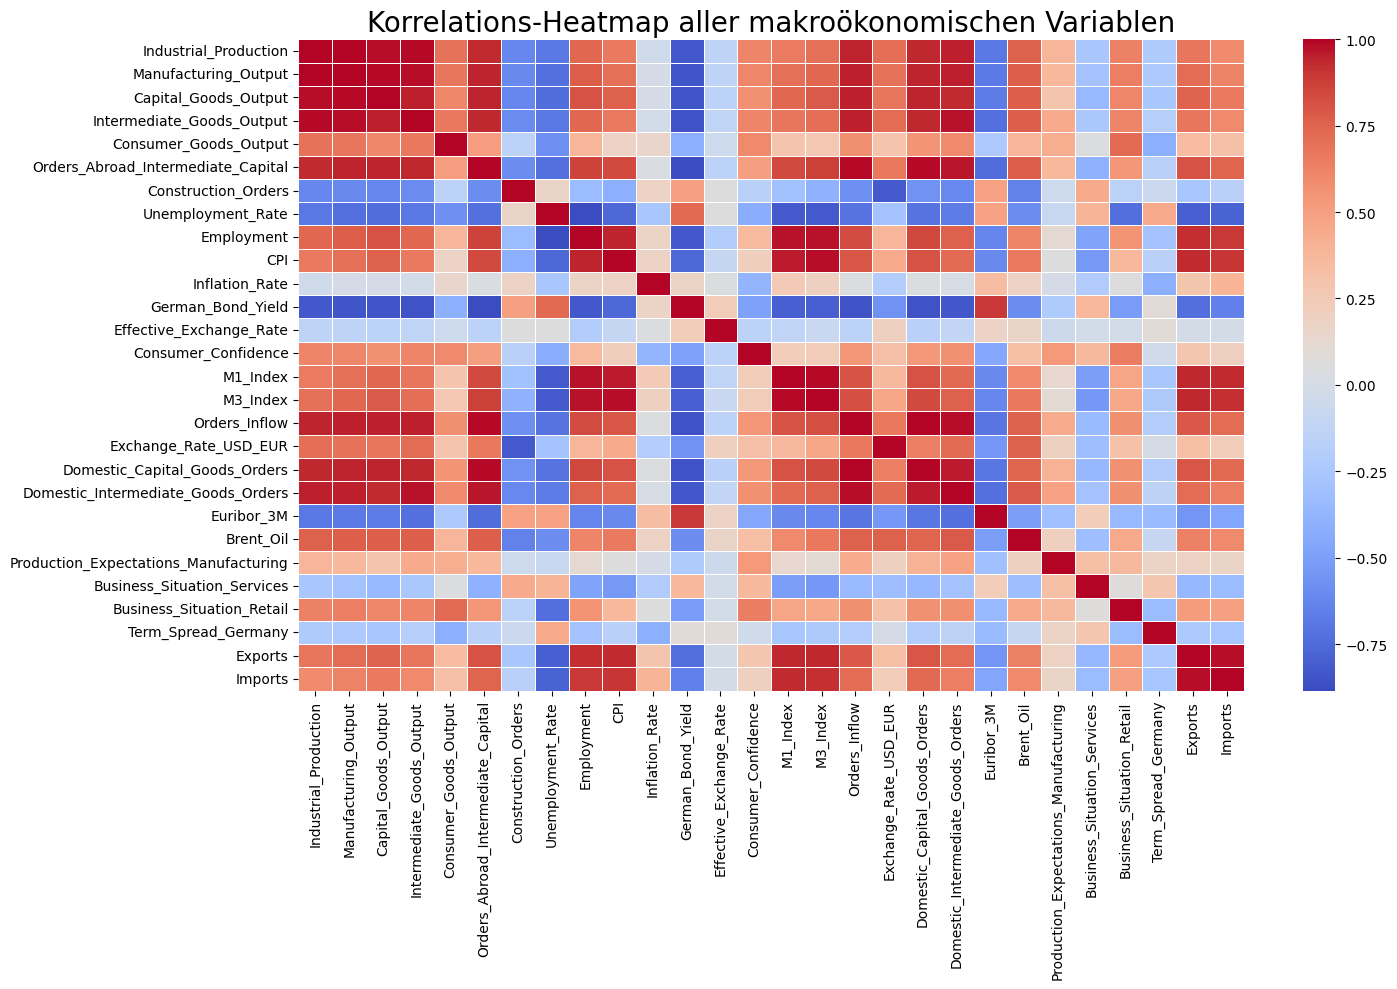


Analyse der stärksten Korrelationen:

Stärkste positive Korrelationen:


,,0
Imports,Exports,0.983806
M3_Index,CPI,0.983853
Intermediate_Goods_Output,Manufacturing_Output,0.984158
Industrial_Production,Intermediate_Goods_Output,0.986425
M3_Index,M1_Index,0.987123
Capital_Goods_Output,Manufacturing_Output,0.990062
Domestic_Capital_Goods_Orders,Orders_Abroad_Intermediate_Capital,0.990483
Orders_Abroad_Intermediate_Capital,Orders_Inflow,0.992034
Domestic_Capital_Goods_Orders,Orders_Inflow,0.995836
Manufacturing_Output,Industrial_Production,0.997849



Stärkste negative Korrelationen:


,,0
Employment,Unemployment_Rate,-0.884643
Orders_Abroad_Intermediate_Capital,German_Bond_Yield,-0.878737
Orders_Inflow,German_Bond_Yield,-0.853708
German_Bond_Yield,Intermediate_Goods_Output,-0.851738
Domestic_Capital_Goods_Orders,German_Bond_Yield,-0.850329
German_Bond_Yield,Capital_Goods_Output,-0.847473
Manufacturing_Output,German_Bond_Yield,-0.841011
German_Bond_Yield,Domestic_Intermediate_Goods_Orders,-0.840434
Industrial_Production,German_Bond_Yield,-0.832560
German_Bond_Yield,Employment,-0.830979


In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Korrelationsanalyse ---")

# Berechne die Korrelationsmatrix für alle numerischen Variablen
correlation_matrix = df.select_dtypes(include=['number']).corr()

# 1. Korrelations-Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Korrelations-Heatmap aller makroökonomischen Variablen', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Identifiziere die höchsten positiven und negativen Korrelationen
print("\nAnalyse der stärksten Korrelationen:\n")

# Create a writable copy of the correlation_matrix for diagonal modification
correlation_matrix_for_diagonal = correlation_matrix.copy()

# Setze die Diagonale (Korrelation einer Variable mit sich selbst) auf NaN, um sie bei der Suche zu ignorieren
# Using .mask with an identity matrix to set the diagonal to NaN, which is a robust way to avoid read-only errors.
correlation_matrix_for_diagonal = correlation_matrix_for_diagonal.mask(np.eye(correlation_matrix_for_diagonal.shape[0], dtype=bool))

# Entpacke die Korrelationsmatrix in eine Series für einfache Sortierung
stacked_corr = correlation_matrix_for_diagonal.stack().sort_values()

# Die stärksten positiven Korrelationen (obere 10, ohne sich selbst zu korrelieren)
# Da die Matrix symmetrisch ist, berücksichtigen wir nur einmal jede Paarkorrelation
strongest_positive_corr = stacked_corr[stacked_corr > 0].drop_duplicates().tail(10)
print("Stärkste positive Korrelationen:")
display(strongest_positive_corr)

# Die stärksten negativen Korrelationen (untere 10, ohne sich selbst zu korrelieren)
strongest_negative_corr = stacked_corr[stacked_corr < 0].drop_duplicates().head(10)
print("\nStärkste negative Korrelationen:")
display(strongest_negative_corr)


**Zeitreihenvisualisierung**

Für die explorative Zeitreihenanalyse werden sieben repräsentative makroökonomische Variablen ausgewählt: Industrial Production, Unemployment Rate, CPI, German Bond Yield, Euribor 3M, Brent Oil und Term Spread Germany. Die Auswahl deckt unterschiedliche ökonomische Bereiche ab, darunter Realwirtschaft, Arbeitsmarkt, Preisentwicklung, Geld- und Kapitalmarkt sowie Rohstoffpreise. Ziel der Visualisierung ist es, zeitliche Entwicklungen, Trends, konjunkturelle Schwankungen und auffällige Veränderungen der Indikatoren über den Untersuchungszeitraum zu erkennen. Die Darstellung dient damit einer ersten visuellen Beurteilung der Zeitreiheneigenschaften vor der anschließenden statistischen Stationaritätsanalyse.


--- Zeitreihenvisualisierung ausgewählter makroökonomischer Variablen ---


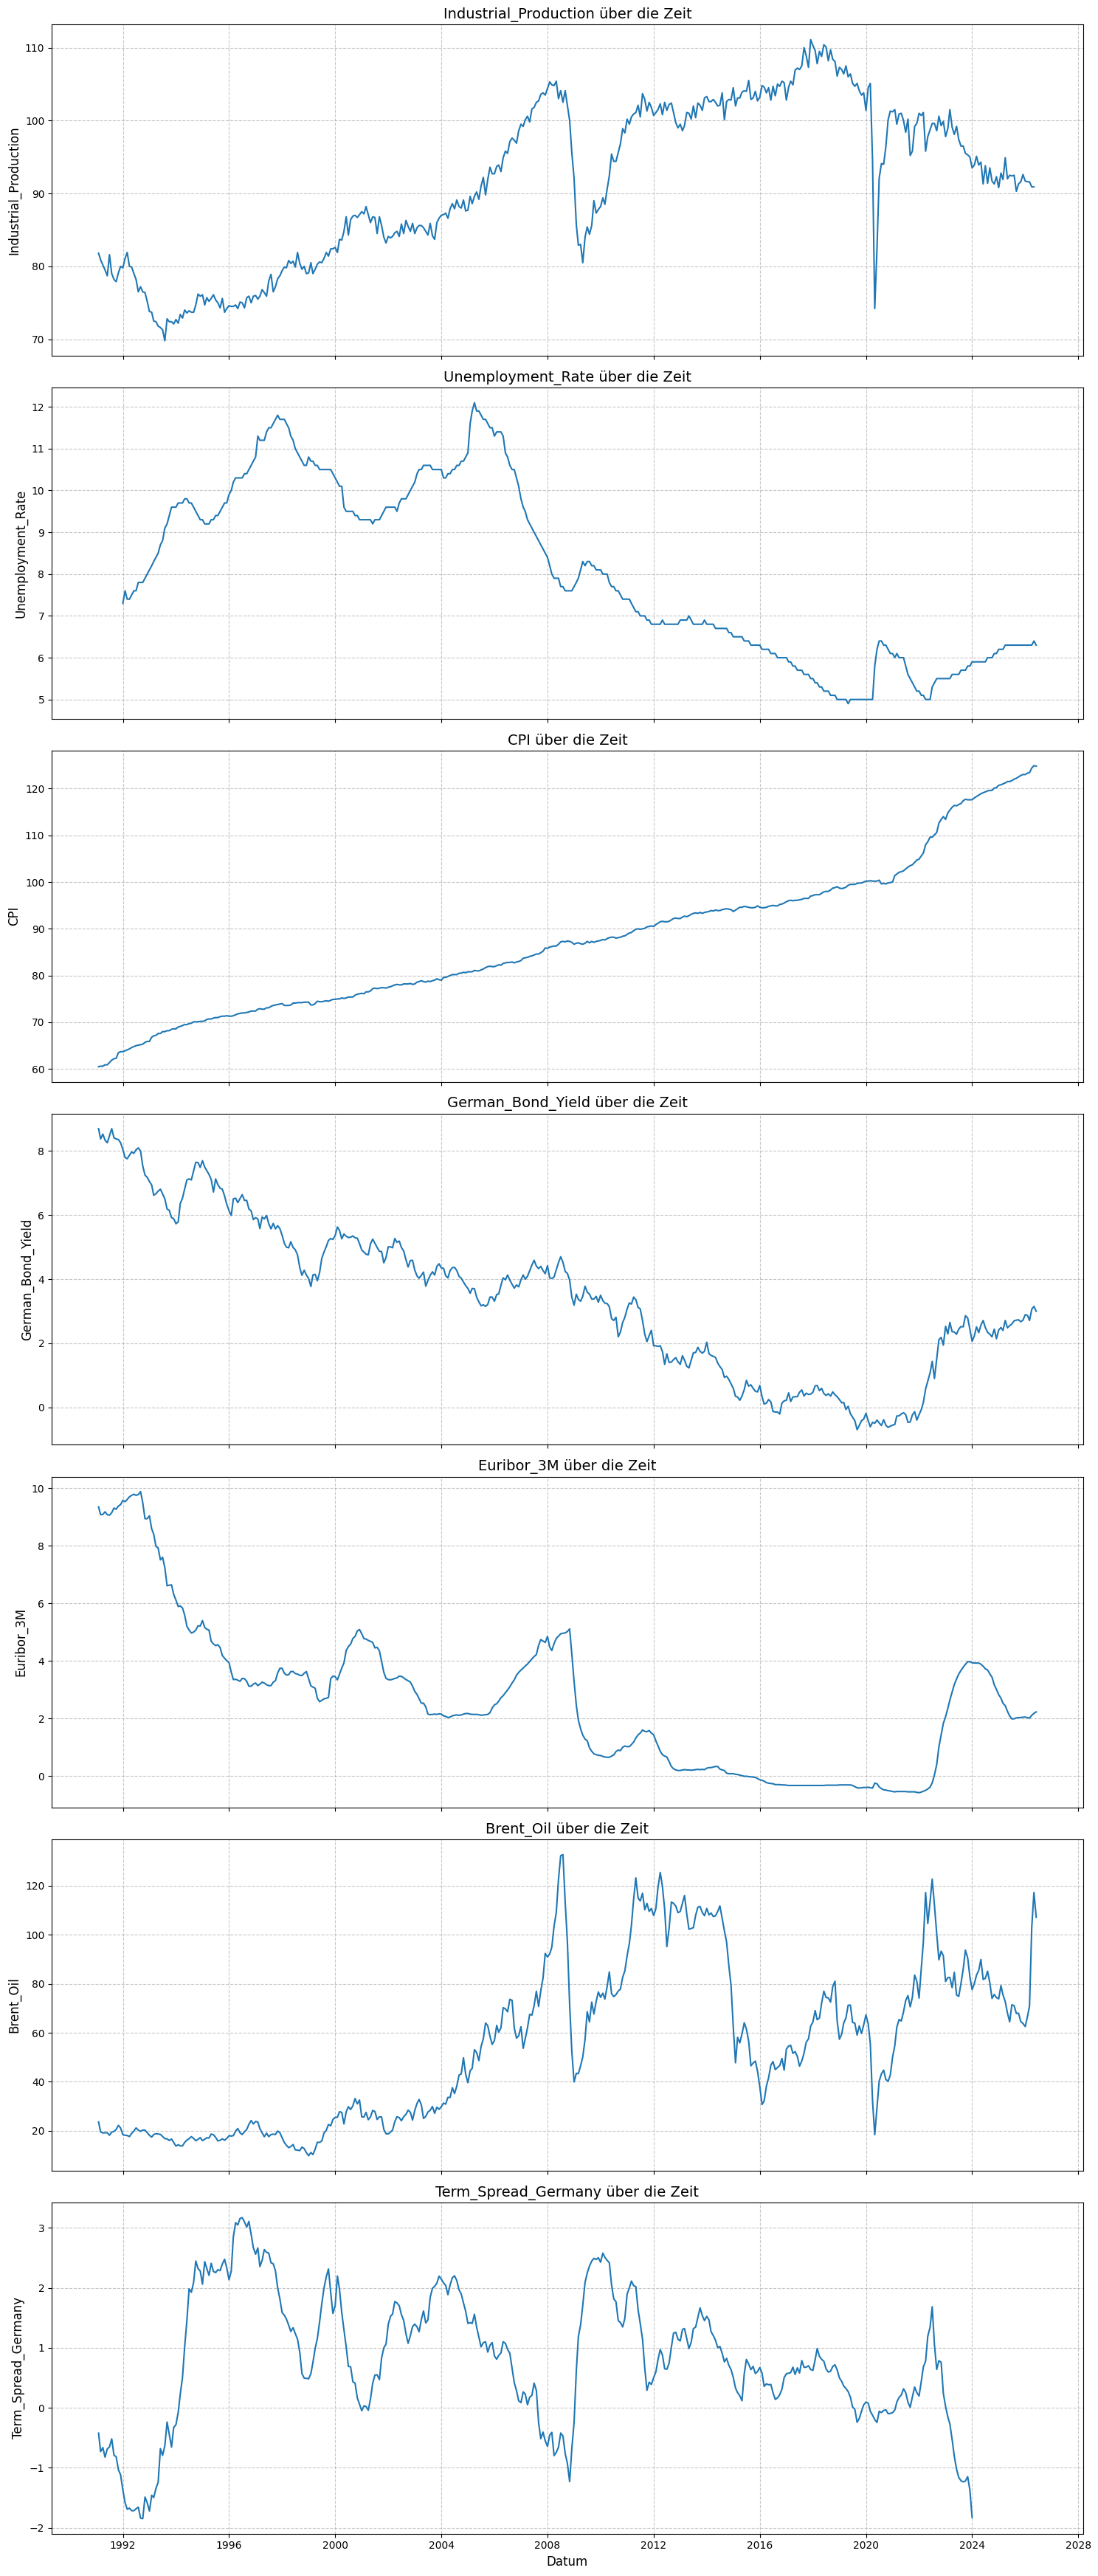

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # Import the date formatter module

print("\n--- Zeitreihenvisualisierung ausgewählter makroökonomischer Variablen ---")

# Liste der ausgewählten Schlüsselvariablen zur Visualisierung
key_variables = [
    'Industrial_Production',
    'Unemployment_Rate',
    'CPI',
    'German_Bond_Yield',
    'Euribor_3M',
    'Brent_Oil',
    'Term_Spread_Germany'
]

# Erstelle Subplots für jede Schlüsselvariable
fig, axes = plt.subplots(len(key_variables), 1, figsize=(15, 5 * len(key_variables)), sharex=True)

for i, var in enumerate(key_variables):
    sns.lineplot(x='Datum', y=var, data=df, ax=axes[i])
    axes[i].set_title(f'{var} über die Zeit', fontsize=14)
    axes[i].set_ylabel(var, fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Setze die X-Achsenbeschriftung und Formattierung für alle Subplots
ax.xaxis.set_major_locator(mdates.YearLocator(4))

# Setze den X-Achsen-Formatierer, um nur die Jahre anzuzeigen
# X-Achse übersichtlich formatieren
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Datum', fontsize=12)

plt.tight_layout()
plt.show()

**Verteilungsanalyse**

Dieser Schritt konzentriert sich auf die Analyse der Verteilungen ausgewählter makroökonomischer Variablen mittels Histogrammen und Boxplots. Ziel ist es, die Form der Verteilung, die Präsenz von Ausreißern sowie die zentrale Tendenz und Streuung der Daten zu untersuchen. Ein tiefes Verständnis der Verteilungseigenschaften jeder Variable ist entscheidend für die Auswahl geeigneter Modellierungsansätze und potenzieller Datentransformationen, um robuste und zuverlässige Prognosemodelle zu entwickeln.


--- Analyse der Verteilungen (Histogramme und Boxplots) ---


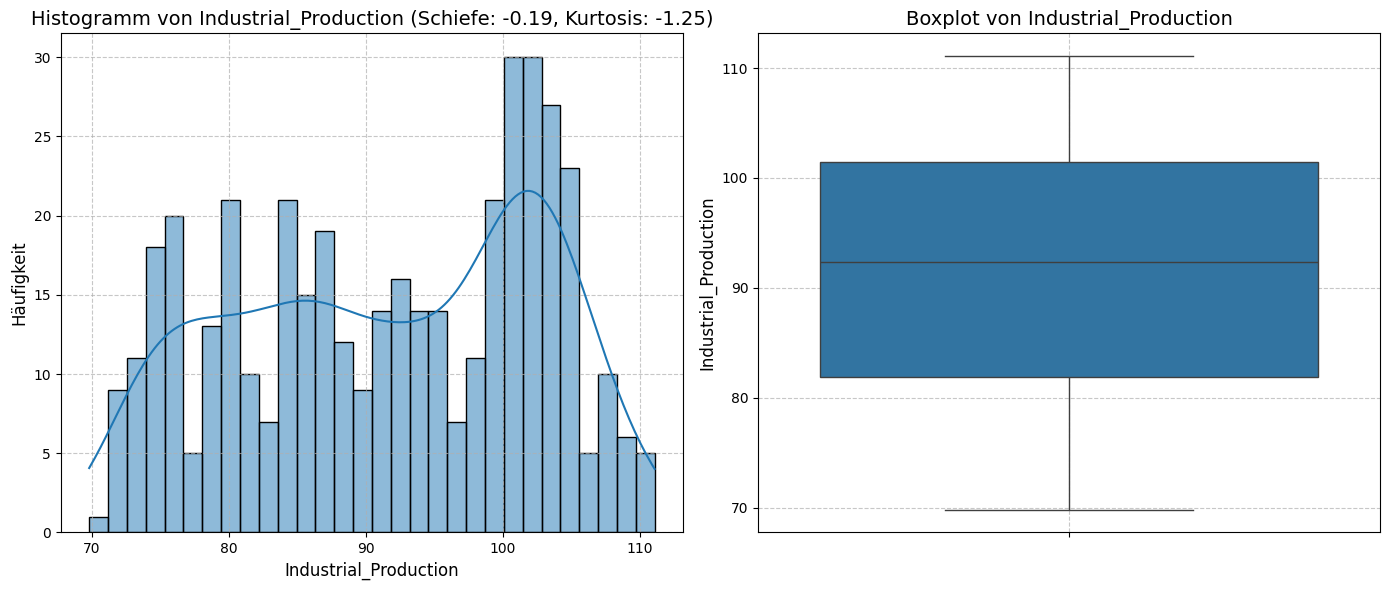

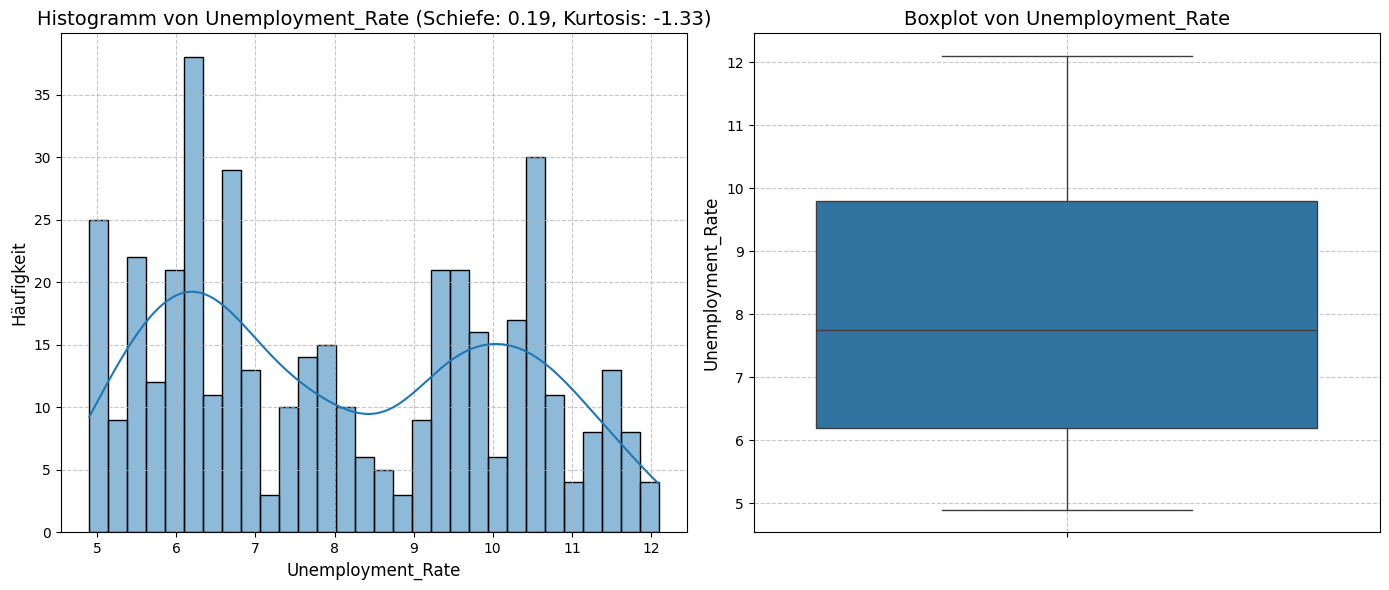

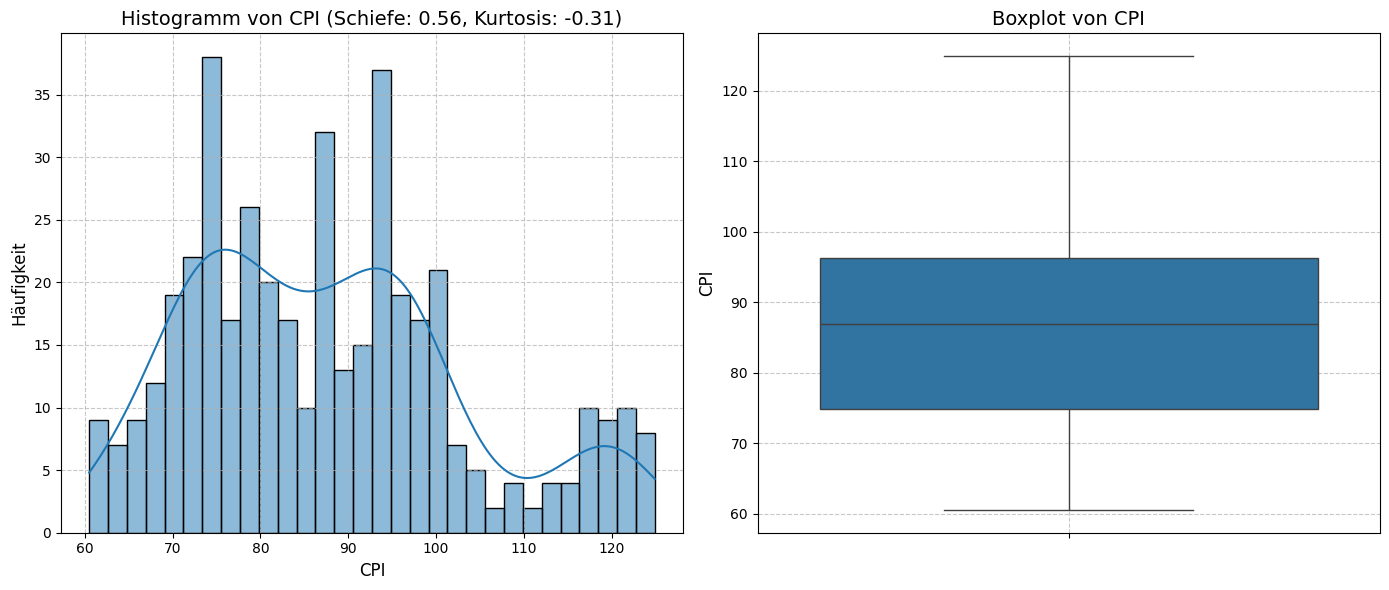

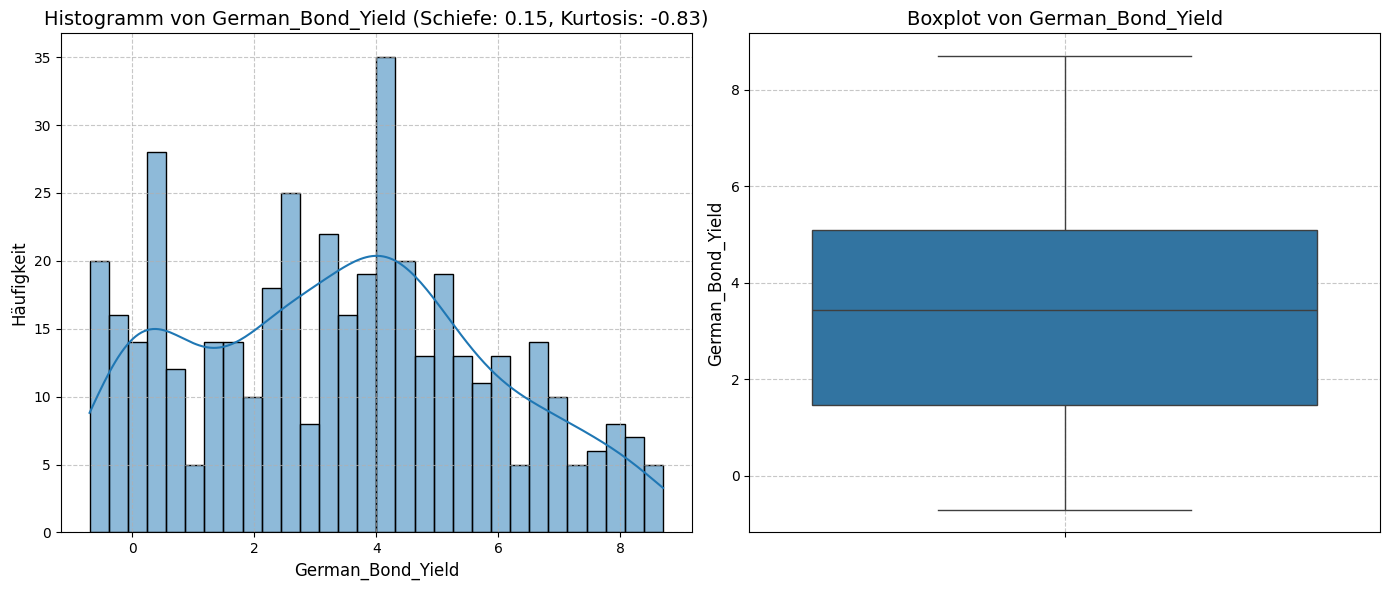

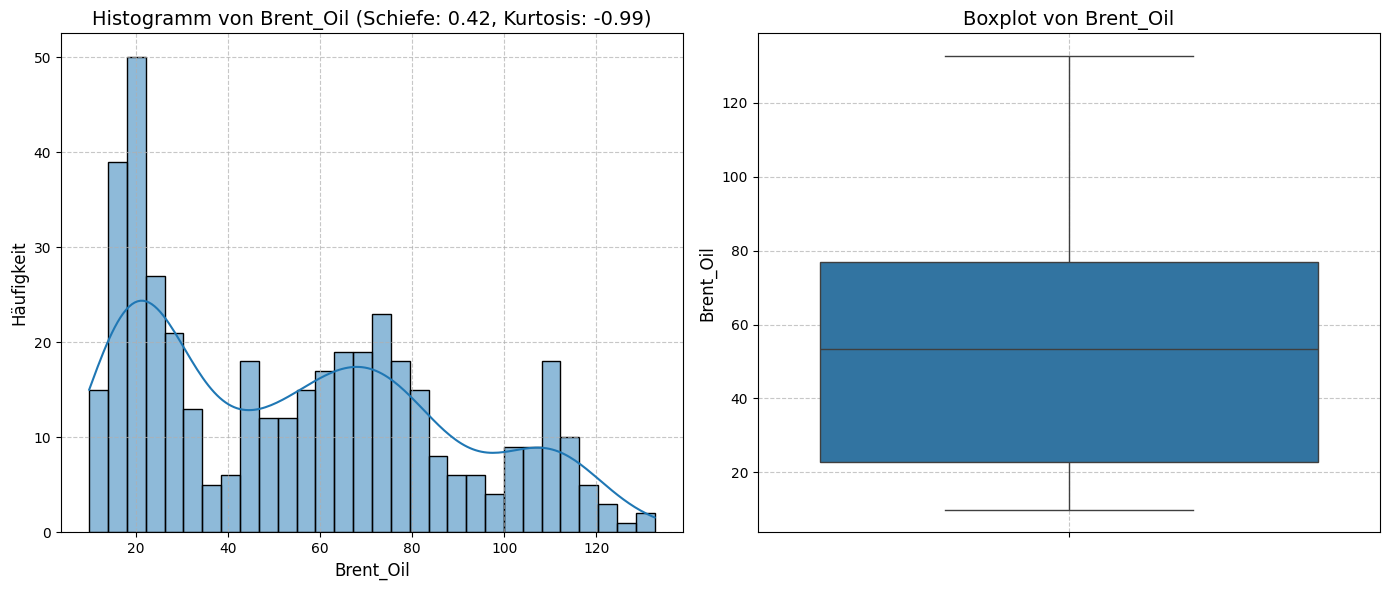

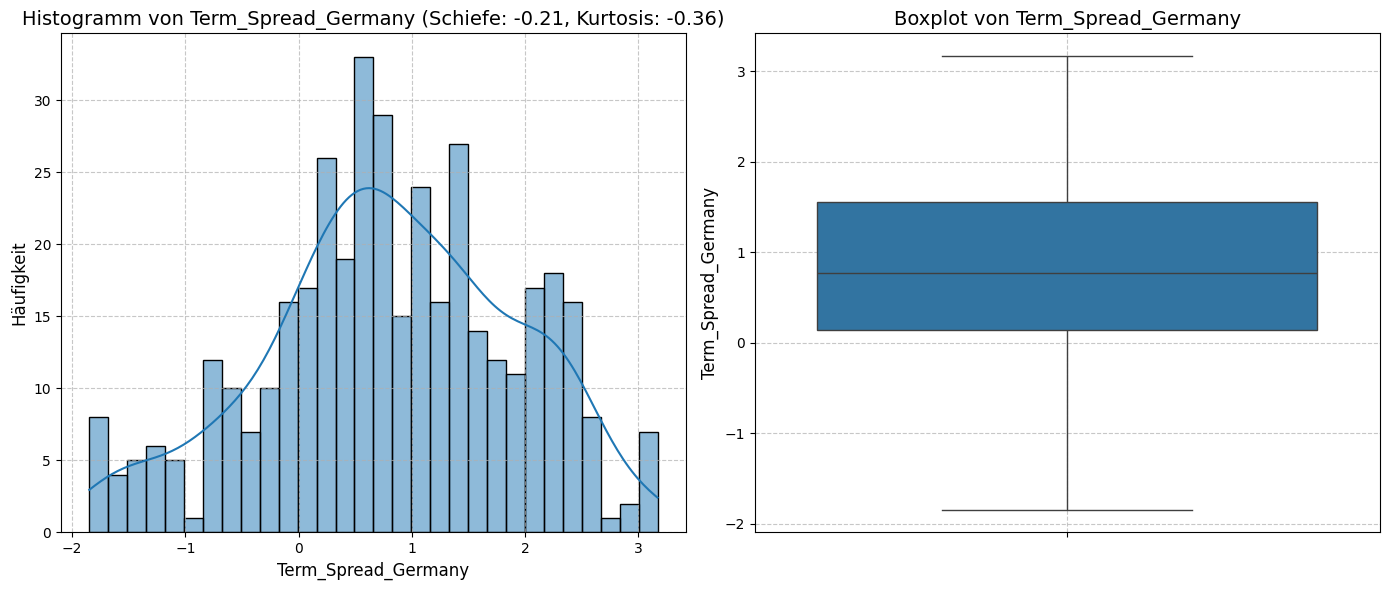

Verteilungsanalyse abgeschlossen.


In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Analyse der Verteilungen (Histogramme und Boxplots) ---")

# Auswahl repräsentativer Variablen für die Verteilungsanalyse
# Diese Auswahl sollte verschiedene Typen von Verteilungen und ökonomische Bedeutung abdecken
distribution_variables = [
    'Industrial_Production',
    'Unemployment_Rate',
    'CPI',
    'German_Bond_Yield',
    'Brent_Oil',
    'Term_Spread_Germany'
]

# Erstelle Histogramme und Boxplots für die ausgewählten Variablen
for var in distribution_variables:
    plt.figure(figsize=(14, 6))

    # Histogramm
    plt.subplot(1, 2, 1) # 1 Reihe, 2 Spalten, 1. Plot
    sns.histplot(df[var].dropna(), kde=True, bins=30)
    plt.title(f'Histogramm von {var} (Schiefe: {df[var].skew():.2f}, Kurtosis: {df[var].kurt():.2f})', fontsize=14)
    plt.xlabel(var, fontsize=12)
    plt.ylabel('Häufigkeit', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Boxplot
    plt.subplot(1, 2, 2) # 1 Reihe, 2 Spalten, 2. Plot
    sns.boxplot(y=df[var].dropna())
    plt.title(f'Boxplot von {var}', fontsize=14)
    plt.ylabel(var, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

print("Verteilungsanalyse abgeschlossen.")

**Zeitreiheneigenschaften**



Dieser Abschnitt untersucht die fundamentalen Zeitreiheneigenschaften der relevantesten Variablen, insbesondere deren Stationarität und Autokorrelation. Mittels des Augmented Dickey-Fuller (ADF) Tests wird die Anwesenheit einer Einheitswurzel geprüft, während ACF- und PACF-Plots die Abhängigkeit einer Zeitreihe von ihren eigenen verzögerten Werten aufzeigen. Diese Analyse ist unerlässlich, da viele Zeitreihenmodelle und Machine-Learning-Algorithmen eine stationäre Datenbasis voraussetzen oder von ihr profitieren, um valide und interpretierbare Ergebnisse zu liefern


--- Analyse der Zeitreiheneigenschaften (Stationarität, Autokorrelation) ---

--- ADF Test für: Industrial_Production ---
ADF Statistik: -1.6603
p-Wert: 0.4517
Kritische Werte:
    1%: -3.4460
    5%: -2.8684
    10%: -2.5704
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)


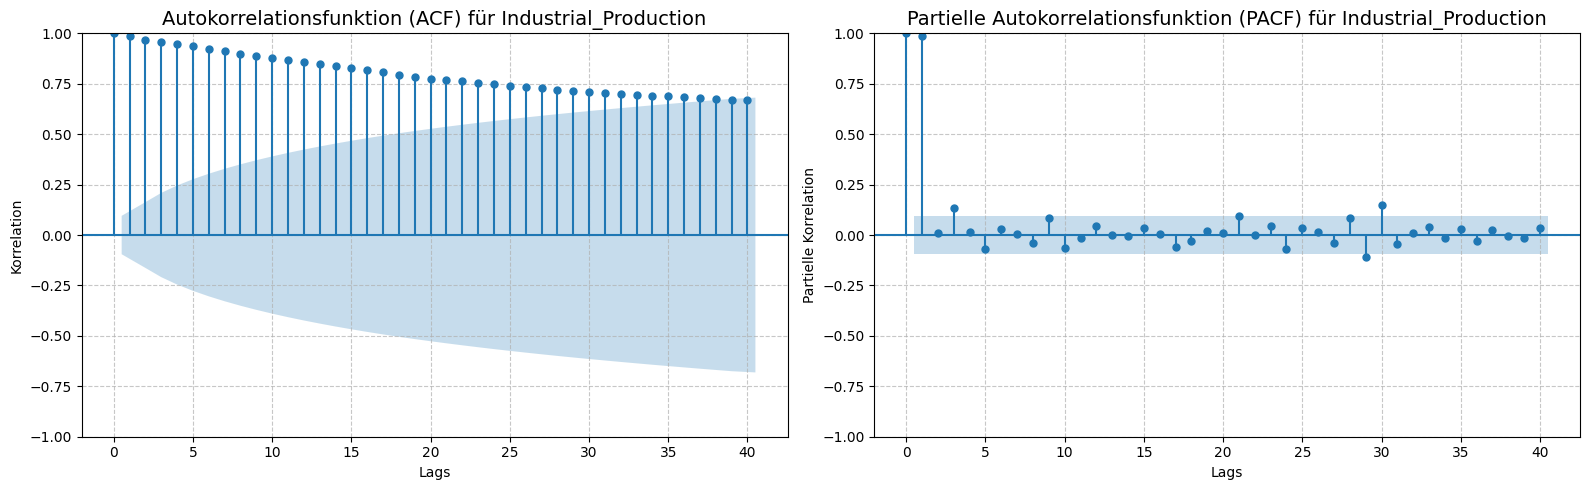


--- ADF Test für: Unemployment_Rate ---
ADF Statistik: -0.9082
p-Wert: 0.7853
Kritische Werte:
    1%: -3.4464
    5%: -2.8686
    10%: -2.5705
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)


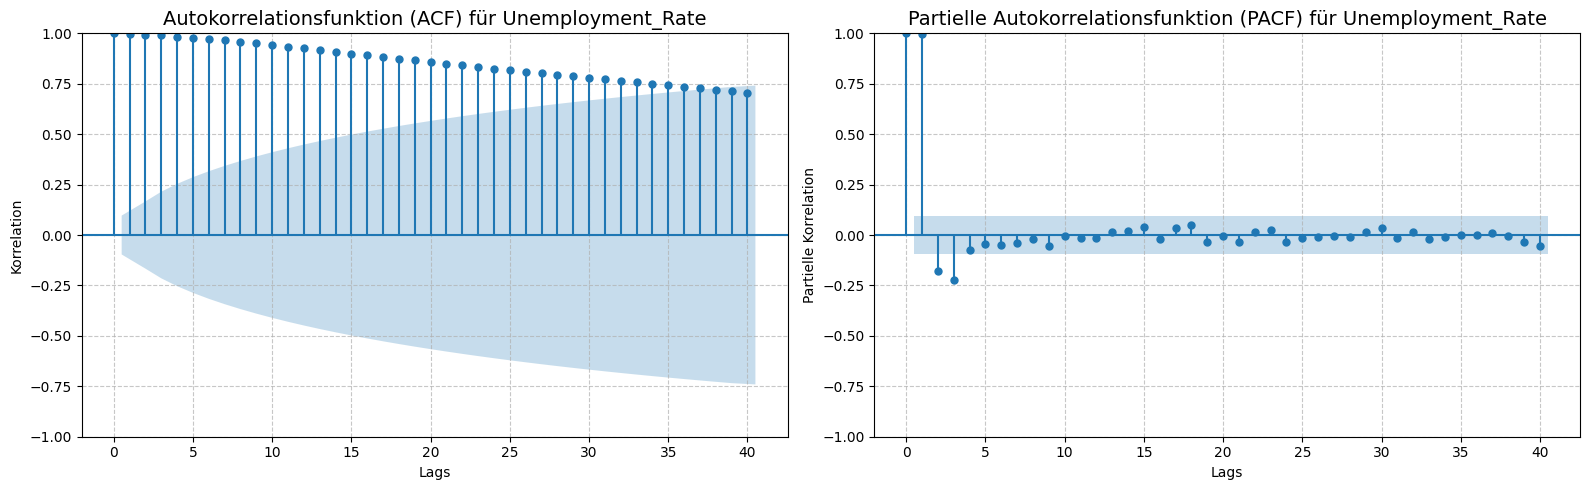


--- ADF Test für: CPI ---
ADF Statistik: 1.4566
p-Wert: 0.9974
Kritische Werte:
    1%: -3.4461
    5%: -2.8685
    10%: -2.5705
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)


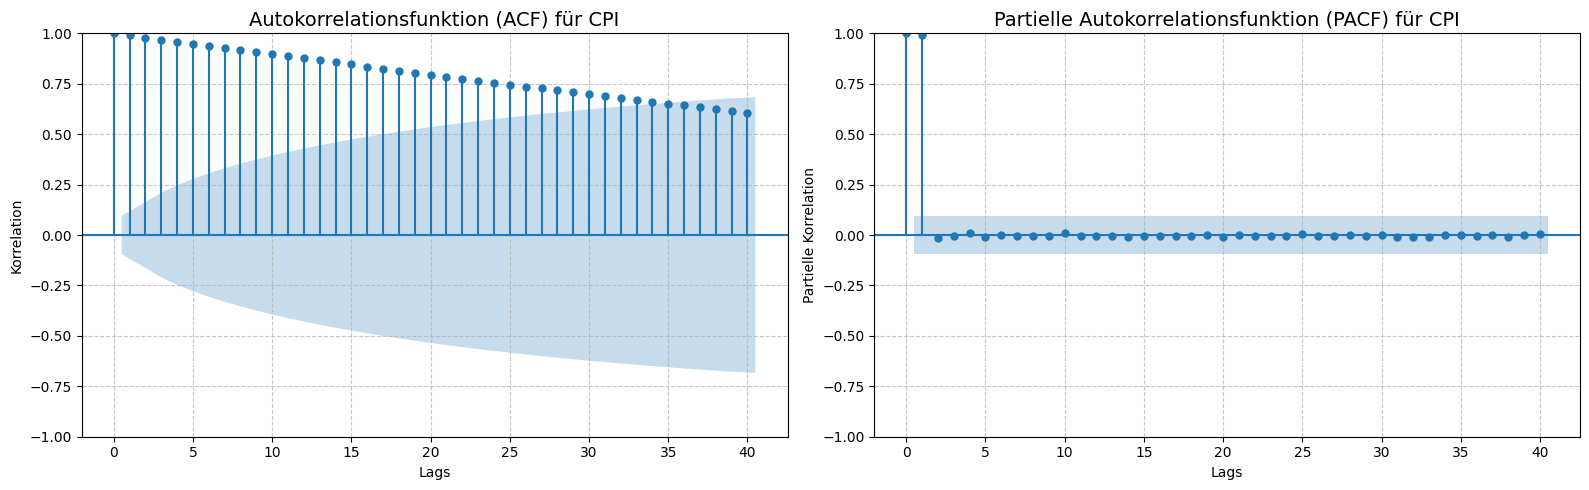


--- ADF Test für: German_Bond_Yield ---
ADF Statistik: -2.0538
p-Wert: 0.2635
Kritische Werte:
    1%: -3.4460
    5%: -2.8684
    10%: -2.5704
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)


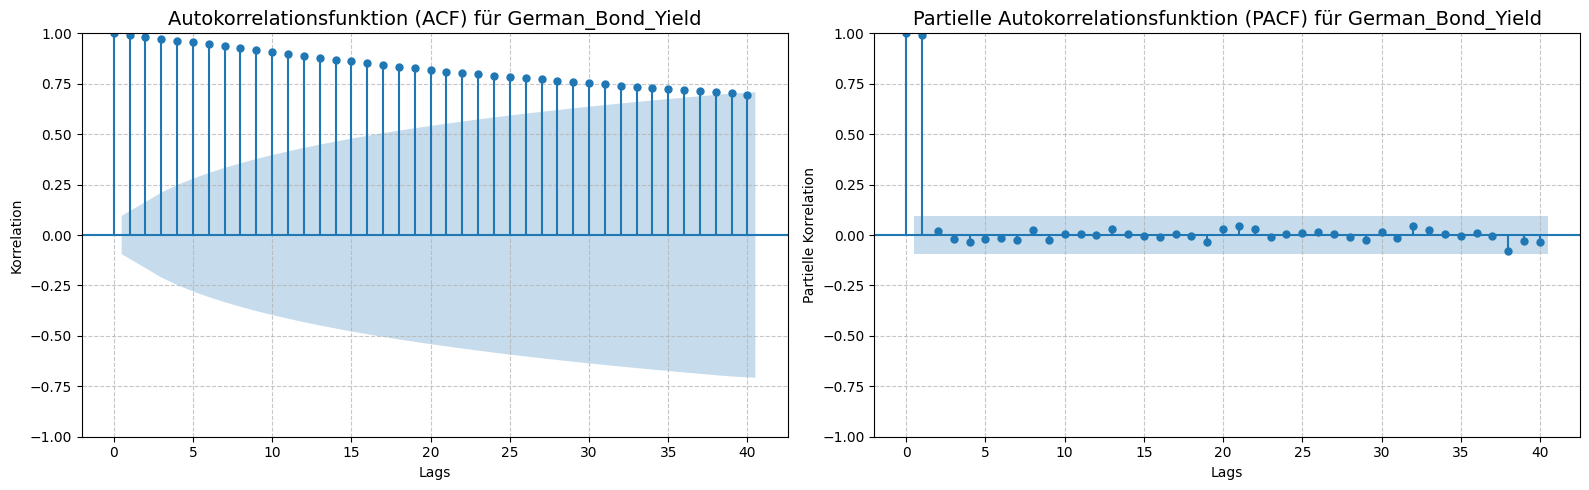


--- ADF Test für: Euribor_3M ---
ADF Statistik: -2.7081
p-Wert: 0.0727
Kritische Werte:
    1%: -3.4460
    5%: -2.8684
    10%: -2.5704
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)


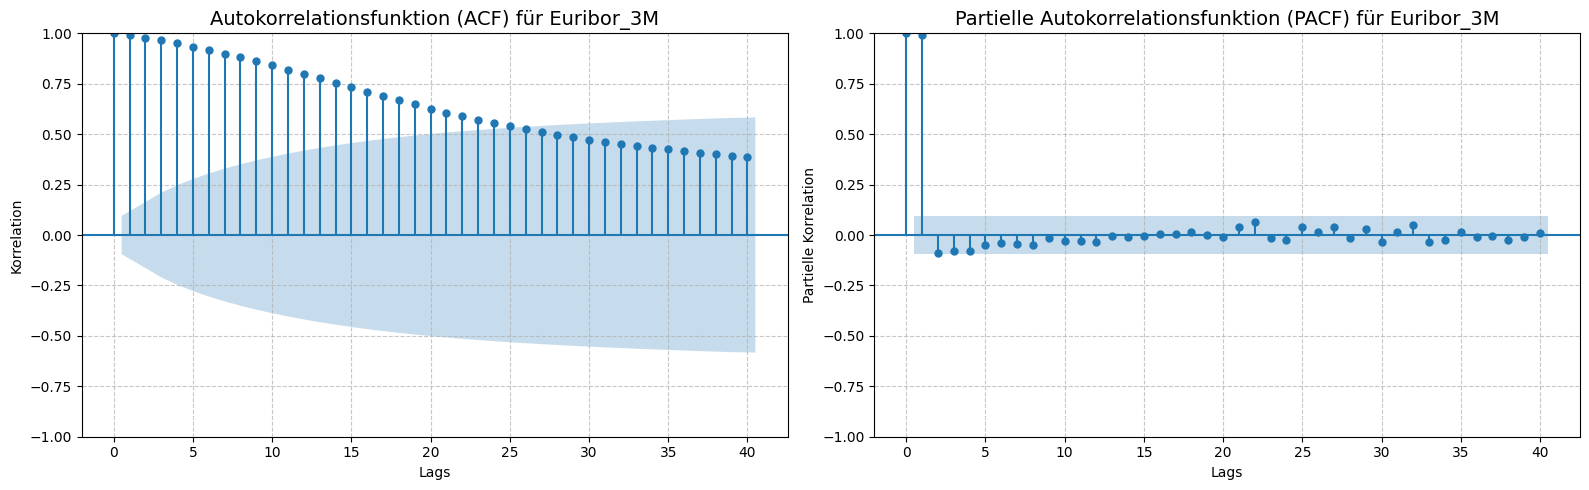


--- ADF Test für: Term_Spread_Germany ---
ADF Statistik: -2.6760
p-Wert: 0.0783
Kritische Werte:
    1%: -3.4471
    5%: -2.8689
    10%: -2.5707
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)


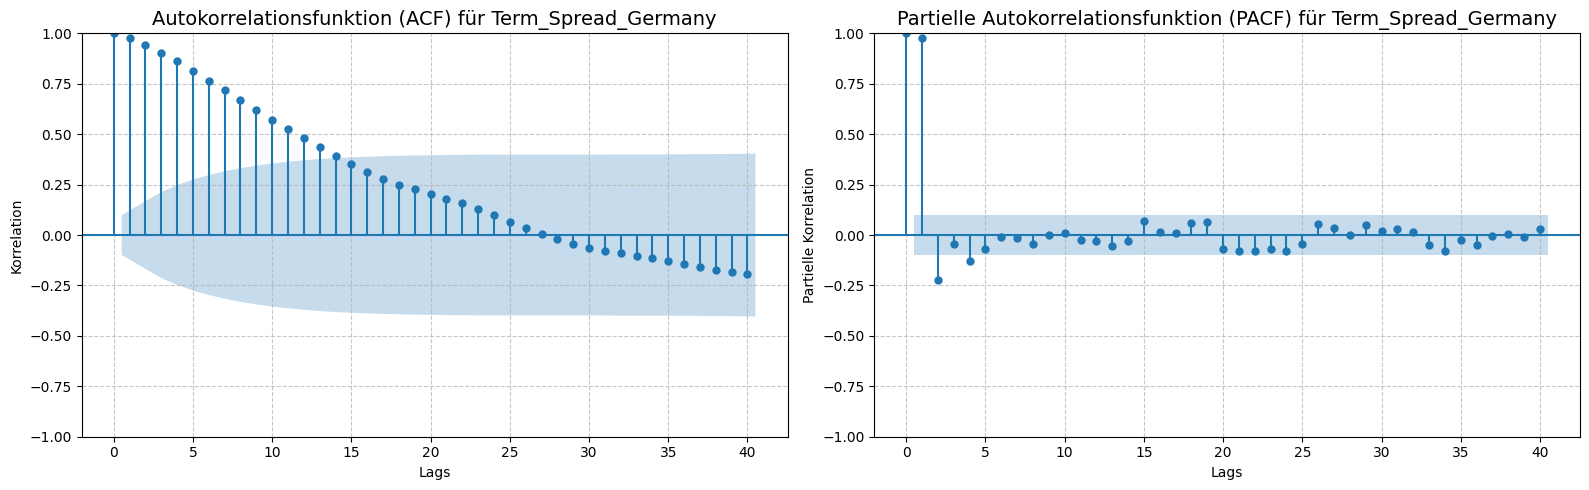

Zeitreiheneigenschaften Analyse abgeschlossen.


In [177]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import pandas as pd

print("\n--- Analyse der Zeitreiheneigenschaften (Stationarität, Autokorrelation) ---")

# Auswahl relevanter Variablen für die Zeitreihenanalyse
# Diese Variablen sollten für die Rezessionsprognose von Bedeutung sein
timeseries_variables = [
    'Industrial_Production',
    'Unemployment_Rate',
    'CPI',
    'German_Bond_Yield',
    'Euribor_3M',
    'Term_Spread_Germany'
]

# Funktion zur Durchführung des Augmented Dickey-Fuller Tests
def perform_adfuller_test(series, name):
    result = adfuller(series.dropna())
    print(f'\n--- ADF Test für: {name} ---')
    print(f'ADF Statistik: {result[0]:.4f}')
    print(f'p-Wert: {result[1]:.4f}')
    print('Kritische Werte:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    if result[1] <= 0.05:
        print('--> Die Zeitreihe ist stationär (p-Wert <= 0.05)')
    else:
        print('--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)')

# ADF Tests und ACF/PACF Plots für ausgewählte Variablen
for var in timeseries_variables:
    # ADF Test
    perform_adfuller_test(df[var], var)

    # ACF und PACF Plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ACF Plot
    plot_acf(df[var].dropna(), lags=40, ax=axes[0])
    axes[0].set_title(f'Autokorrelationsfunktion (ACF) für {var}', fontsize=14)
    axes[0].set_xlabel('Lags')
    axes[0].set_ylabel('Korrelation')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # PACF Plot
    plot_pacf(df[var].dropna(), lags=40, ax=axes[1])
    axes[1].set_title(f'Partielle Autokorrelationsfunktion (PACF) für {var}', fontsize=14)
    axes[1].set_xlabel('Lags')
    axes[1].set_ylabel('Partielle Korrelation')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

print("Zeitreiheneigenschaften Analyse abgeschlossen.")

**Erste Stationaritätsdiagnostik und Autokorrelationsanalyse**

Dieser Schritt erweitert die vorherige explorative Untersuchung durch die systematische Anwendung des Augmented-Dickey-Fuller-Tests (ADF) auf alle numerischen Variablen des Datensatzes. Dadurch werden stationäre und nichtstationäre Zeitreihen identifiziert. Die Ergebnisse dienen als Grundlage für die Entscheidung über erforderliche Transformationen in der anschließenden Datenvorverarbeitung.

In [178]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

print("\n--- Stationaritätsanalyse für alle numerischen Variablen (ADF-Test) ---")

# Funktion zur Durchführung des Augmented Dickey-Fuller Tests
def perform_adfuller_test(series, name):
    # Drop NaNs to ensure the test can run
    series_cleaned = series.dropna()
    if len(series_cleaned) < 5: # ADF test requires at least 5 observations
        print(f'\n--- ADF Test für: {name} ---')
        print(f'Nicht genügend Datenpunkte ({len(series_cleaned)}) für den ADF-Test nach NaN-Entfernung. Überspringe.')
        return

    try:
        result = adfuller(series_cleaned)
        print(f'\n--- ADF Test für: {name} ---')
        print(f'ADF Statistik: {result[0]:.4f}')
        print(f'p-Wert: {result[1]:.4f}')
        print('Kritische Werte:')
        for key, value in result[4].items():
            print(f'    {key}: {value:.4f}')
        if result[1] <= 0.05:
            print('--> Die Zeitreihe ist stationär (p-Wert <= 0.05)')
        else:
            print('--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)')
    except Exception as e:
        print(f'\n--- ADF Test für: {name} ---')
        print(f'Fehler bei der Durchführung des ADF-Tests: {e}')

# Führe ADF-Tests für alle numerischen Spalten durch
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    perform_adfuller_test(df[col], col)

print("Umfassende Stationaritätsanalyse abgeschlossen.")


--- Stationaritätsanalyse für alle numerischen Variablen (ADF-Test) ---

--- ADF Test für: Industrial_Production ---
ADF Statistik: -1.6603
p-Wert: 0.4517
Kritische Werte:
    1%: -3.4460
    5%: -2.8684
    10%: -2.5704
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)

--- ADF Test für: Manufacturing_Output ---
ADF Statistik: -1.6241
p-Wert: 0.4706
Kritische Werte:
    1%: -3.4460
    5%: -2.8684
    10%: -2.5704
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)

--- ADF Test für: Capital_Goods_Output ---
ADF Statistik: -1.5115
p-Wert: 0.5278
Kritische Werte:
    1%: -3.4460
    5%: -2.8684
    10%: -2.5704
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)

--- ADF Test für: Intermediate_Goods_Output ---
ADF Statistik: -1.6608
p-Wert: 0.4514
Kritische Werte:
    1%: -3.4459
    5%: -2.8684
    10%: -2.5704
--> Die Zeitreihe ist nicht stationär (p-Wert > 0.05)

--- ADF Test für: Consumer_Goods_Output ---
ADF Statistik: -2.2452
p-Wert: 0.1903
Kritische Werte:
    1%: -3.44

**Definition und Datierung der Zielvariable „Rezession“**

Die Rezessionsprognose wird als binäres Klassifikationsproblem formuliert. Die Zielvariable Rezession erhält den Wert 1 für Rezessionsmonate und 0 für Expansionsmonate. Für die historische Datierung werden die Rezessionsphasen des Sachverständigenrats zur Begutachtung der gesamtwirtschaftlichen Entwicklung (GCEE) verwendet: Februar 1992 bis Juli 1993, Februar 2001 bis Juni 2003, Januar 2008 bis April 2009 sowie Februar bis April 2020. Für den Zeitraum nach April 2020 wird die Zielvariable anhand der technischen Rezessionsregel fortgeführt. Dabei wird eine Rezession identifiziert, wenn das reale BIP in zwei aufeinanderfolgenden Quartalen gegenüber dem jeweiligen Vorquartal sinkt. Die auf Quartalsebene identifizierten Rezessionsphasen werden anschließend den entsprechenden Monaten zugeordnet, sodass eine durchgängige monatliche Zielvariable für die spätere Klassifikation entsteht.

In [179]:
!pip install -q dbnomics

import pandas as pd
from dbnomics import fetch_series

# Alte Hilfsspalten entfernen, falls die Zelle bereits ausgeführt wurde
helper_columns = [
    "Quartal",
    "GDP_Growth_QoQ",
    "Technical_Recession_Q"
]

df = df.drop(
    columns=[col for col in helper_columns if col in df.columns]
)

# Datum sicher als Datumsformat definieren
df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce")
df = df.sort_values("Datum").reset_index(drop=True)

# Zielvariable initialisieren
df["Rezession"] = 0

# Hoch- und Tiefpunkte der historischen GCEE-Rezessionsphasen
gcee_recessions = [
    ("1992-02-29", "1993-07-31"),
    ("2001-02-28", "2003-06-30"),
    ("2008-01-31", "2009-04-30"),
    ("2020-02-29", "2020-04-30")
]
# Rezession beginnt nach dem Hochpunkt und endet mit dem Tiefpunkt
for peak, trough in gcee_recessions:
    df.loc[
        (df["Datum"] > peak) &
        (df["Datum"] <= trough),
        "Rezession"
    ] = 1

# Quartalsweise reale BIP-Daten der Deutschen Bundesbank abrufen
gdp = fetch_series(
    "BUBA/BBNZ1/Q.DE.Y.H.0000.L"
)[["period", "value"]].copy()

gdp.columns = ["Quartal", "Real_GDP"]

# Quartalsformat erstellen und chronologisch sortieren
gdp["Quartal"] = pd.PeriodIndex(gdp["Quartal"], freq="Q")
gdp = gdp.sort_values("Quartal").reset_index(drop=True)

# BIP-Wachstum gegenüber dem Vorquartal berechnen
gdp["GDP_Growth_QoQ"] = (
    gdp["Real_GDP"].pct_change(fill_method=None) * 100
)

# Negative Wachstumsquartale identifizieren
negative_growth = gdp["GDP_Growth_QoQ"] < 0

# Technische Rezession:
# zwei aufeinanderfolgende Quartale mit negativem BIP-Wachstum
gdp["Technical_Recession_Q"] = (
    (negative_growth & negative_growth.shift(1, fill_value=False)) |
    (negative_growth & negative_growth.shift(-1, fill_value=False))
).astype(int)

# Quartalsinformation auf den monatlichen Datensatz übertragen
df["Quartal"] = df["Datum"].dt.to_period("Q")

df = df.merge(
    gdp[
        ["Quartal", "GDP_Growth_QoQ", "Technical_Recession_Q"]
    ],
    on="Quartal",
    how="left",
    validate="many_to_one"
)

# Technische Rezessionsregel ab Mai 2020 verwenden
df.loc[
    (df["Datum"] >= "2020-05-01") &
    (df["Technical_Recession_Q"] == 1),
    "Rezession"
] = 1

df["Rezession"] = df["Rezession"].astype(int)

# Kontrolle
print("Zielvariable 'Rezession' wurde erfolgreich erstellt.")

print("\nKlassenverteilung:")
print(df["Rezession"].value_counts().sort_index())

print("\nKlassenverteilung in Prozent:")
print(
    (df["Rezession"].value_counts(normalize=True)
     .sort_index() * 100)
    .round(2)
)

Zielvariable 'Rezession' wurde erfolgreich erstellt.

Klassenverteilung:
Rezession
0    337
1     88
Name: count, dtype: int64

Klassenverteilung in Prozent:
Rezession
0    79.29
1    20.71
Name: proportion, dtype: float64


In [180]:
# Alle als Rezession klassifizierten Monate anzeigen

rezessionsmonate = df.loc[
    df["Rezession"] == 1,
    ["Datum", "GDP_Growth_QoQ", "Technical_Recession_Q", "Rezession"]
].copy()

display(rezessionsmonate)

print(f"\nAnzahl Rezessionsmonate insgesamt: {len(rezessionsmonate)}")

,Datum,GDP_Growth_QoQ,Technical_Recession_Q,Rezession
14,1992-03-31,1.373126,0.0,1
15,1992-04-30,-0.621977,1.0,1
16,1992-05-31,-0.621977,1.0,1
17,1992-06-30,-0.621977,1.0,1
18,1992-07-31,-0.236439,1.0,1
...,...,...,...,...
412,2025-05-31,-0.200229,1.0,1
413,2025-06-30,-0.200229,1.0,1
414,2025-07-31,-0.038215,1.0,1
415,2025-08-31,-0.038215,1.0,1



Anzahl Rezessionsmonate insgesamt: 88


In [181]:
# GCEE-Rezessionsmonate bis April 2020
gcee_kontrolle = df.loc[
    (df["Datum"] <= "2020-04-30") &
    (df["Rezession"] == 1),
    ["Datum", "Rezession"]
]

# Technisch bestimmte Rezessionsmonate ab Mai 2020
technical_kontrolle = df.loc[
    (df["Datum"] >= "2020-05-01") &
    (df["Technical_Recession_Q"] == 1) &
    (df["Rezession"] == 1),
    ["Datum", "GDP_Growth_QoQ", "Technical_Recession_Q", "Rezession"]
]

print("GCEE-Rezessionsmonate:")
display(gcee_kontrolle)
print("Anzahl:", len(gcee_kontrolle))

print("\nTechnische Rezessionsmonate ab Mai 2020:")
display(technical_kontrolle)
print("Anzahl:", len(technical_kontrolle))

print("\nGesamt:", len(gcee_kontrolle) + len(technical_kontrolle))

GCEE-Rezessionsmonate:


,Datum,Rezession
14,1992-03-31,1
15,1992-04-30,1
16,1992-05-31,1
17,1992-06-30,1
18,1992-07-31,1
...,...,...
217,2009-02-28,1
218,2009-03-31,1
219,2009-04-30,1
350,2020-03-31,1


Anzahl: 62

Technische Rezessionsmonate ab Mai 2020:


,Datum,GDP_Growth_QoQ,Technical_Recession_Q,Rezession
352,2020-05-31,-8.874120,1.0,1
353,2020-06-30,-8.874120,1.0,1
381,2022-10-31,-0.349386,1.0,1
382,2022-11-30,-0.349386,1.0,1
383,2022-12-31,-0.349386,1.0,1
384,2023-01-31,-0.473799,1.0,1
385,2023-02-28,-0.473799,1.0,1
386,2023-03-31,-0.473799,1.0,1
387,2023-04-30,-0.076169,1.0,1
388,2023-05-31,-0.076169,1.0,1


Anzahl: 26

Gesamt: 88


**Klassenverteilung Rezession/Nicht-Rezession analysieren**

Die Zielvariable Rezession ist binär kodiert, wobei 0 für Nicht-Rezession und 1 für Rezession steht. Von insgesamt 425 monatlichen Beobachtungen wurden 337 Monate (79,29 %) als Nicht-Rezessionsmonate und 88 Monate (20,71 %) als Rezessionsmonate klassifiziert.

Damit liegt eine ungleiche Klassenverteilung vor, da Nicht-Rezessionsmonate deutlich häufiger auftreten. Diese Klassenverteilung wird bei der späteren Modellierung und insbesondere bei der Auswahl geeigneter Evaluationsmetriken berücksichtig

--- Klassenverteilung der Zielvariable Rezession ---

Absolute Häufigkeiten:
Rezession
0    337
1     88
Name: count, dtype: int64

Prozentuale Häufigkeiten:
Rezession
0    79.29
1    20.71
Name: proportion, dtype: float64


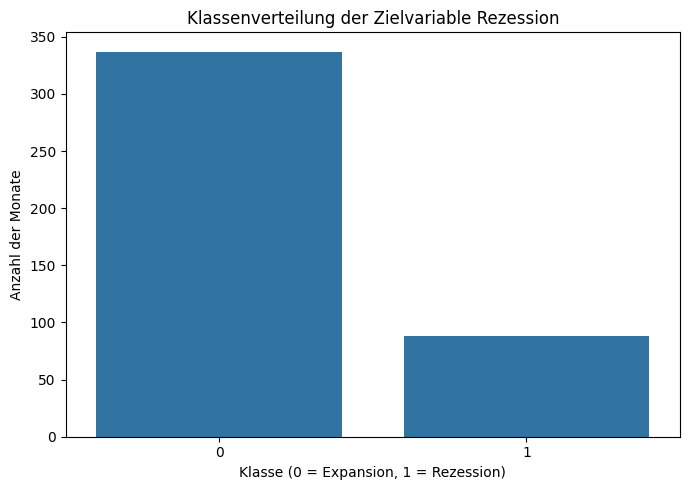

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Klassenverteilung der Zielvariable Rezession ---")

# Absolute Häufigkeiten
class_counts = df["Rezession"].value_counts().sort_index()

# Prozentuale Häufigkeiten
class_percentages = (
    df["Rezession"].value_counts(normalize=True)
    .sort_index() * 100
)

print("\nAbsolute Häufigkeiten:")
print(class_counts)

print("\nProzentuale Häufigkeiten:")
print(class_percentages.round(2))

# Grafische Darstellung
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Rezession"
)

plt.title("Klassenverteilung der Zielvariable Rezession")
plt.xlabel("Klasse (0 = Expansion, 1 = Rezession)")
plt.ylabel("Anzahl der Monate")

plt.tight_layout()
plt.show()

**Finale Datensatzvorbereitung und Speicherung**

Für die finale Excel-Datei wurde zunächst eine Kopie des Datensatzes erstellt, damit der ursprüngliche DataFrame unverändert bleibt. Anschließend wurden die Hilfsspalten Quartal, GDP_Growth_QoQ und Technical_Recession_Q aus der Kopie entfernt, da sie nur zur Konstruktion und Kontrolle der Zielvariable benötigt wurden. Abschließend wurden Spalten, Dimension und Klassenverteilung der Zielvariable Rezession kontrolliert.

In [183]:
# Kopie für die finale Excel-Datei erstellen
df_final = df.copy()

# Technische Hilfsspalten nur aus der Excel-Ausgabe entfernen
helper_columns = [
    "Quartal",
    "GDP_Growth_QoQ",
    "Technical_Recession_Q"
]

df_final = df_final.drop(
    columns=[col for col in helper_columns if col in df_final.columns]
)

# Kontrolle
print("Spalten in finaler Excel-Datei:")
print(df_final.columns.tolist())

print("\nDimension:")
print(df_final.shape)

print("\nRezessionsverteilung:")
print(df_final["Rezession"].value_counts().sort_index())

Spalten in finaler Excel-Datei:
['Datum', 'Industrial_Production', 'Manufacturing_Output', 'Capital_Goods_Output', 'Intermediate_Goods_Output', 'Consumer_Goods_Output', 'Orders_Abroad_Intermediate_Capital', 'Construction_Orders', 'Unemployment_Rate', 'Employment', 'CPI', 'Inflation_Rate', 'German_Bond_Yield', 'Effective_Exchange_Rate', 'Consumer_Confidence', 'M1_Index', 'M3_Index', 'Orders_Inflow', 'Exchange_Rate_USD_EUR', 'Domestic_Capital_Goods_Orders', 'Domestic_Intermediate_Goods_Orders', 'Euribor_3M', 'Brent_Oil', 'Production_Expectations_Manufacturing', 'Business_Situation_Services', 'Business_Situation_Retail', 'Term_Spread_Germany', 'Exports', 'Imports', 'Rezession']

Dimension:
(425, 30)

Rezessionsverteilung:
Rezession
0    337
1     88
Name: count, dtype: int64


**Speichern**

In [184]:
from openpyxl import Workbook

output_file = "eda_dataset.xlsx"

wb = Workbook()
ws = wb.active
ws.title = "EDA_Dataset"

# Spaltennamen
ws.append(list(df_final.columns))

# Daten
for row in df_final.itertuples(index=False, name=None):
    clean_row = [
        value.to_pydatetime() if isinstance(value, pd.Timestamp) else value
        for value in row
    ]
    ws.append(clean_row)

wb.save(output_file)

print("Gespeichert:", output_file)
print("Dimension:", df_final.shape)
print("Rezession vorhanden:", "Rezession" in df_final.columns)

Gespeichert: eda_dataset.xlsx
Dimension: (425, 30)
Rezession vorhanden: True
